# Q1

Processed scale 1/20: sigma=1.00
Processed scale 2/20: sigma=1.26
Processed scale 3/20: sigma=1.53
Processed scale 4/20: sigma=1.79
Processed scale 5/20: sigma=2.05
Processed scale 6/20: sigma=2.32
Processed scale 7/20: sigma=2.58
Processed scale 8/20: sigma=2.84
Processed scale 9/20: sigma=3.11
Processed scale 10/20: sigma=3.37
Processed scale 11/20: sigma=3.63
Processed scale 12/20: sigma=3.89
Processed scale 13/20: sigma=4.16
Processed scale 14/20: sigma=4.42
Processed scale 15/20: sigma=4.68
Processed scale 16/20: sigma=4.95
Processed scale 17/20: sigma=5.21
Processed scale 18/20: sigma=5.47
Processed scale 19/20: sigma=5.74
Processed scale 20/20: sigma=6.00
Raw blobs: 87

Top 10 largest blobs:
 1. Center=(106.0,255.0), Radius=8.49, σ=6.00, Response=0.363
 2. Center=(4.0,275.0), Radius=8.49, σ=6.00, Response=0.288
 3. Center=(179.0,327.0), Radius=8.49, σ=6.00, Response=0.345
 4. Center=(282.0,338.0), Radius=8.49, σ=6.00, Response=0.308
 5. Center=(53.0,174.0), Radius=7.74, σ=5.47, 

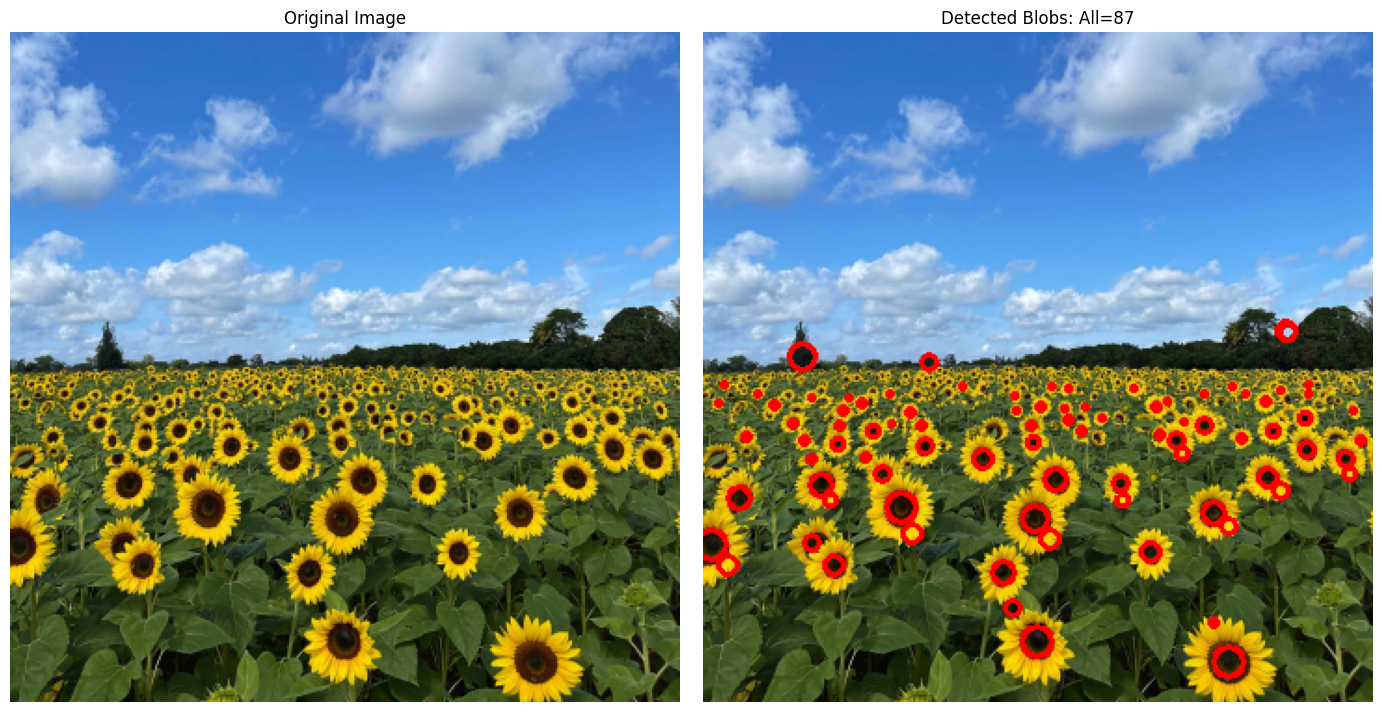

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, laplace, maximum_filter

IMG_PATH = "the_berry_farms_sunflower_field.jpeg"
img = cv.imread(IMG_PATH, cv.IMREAD_REDUCED_COLOR_4)

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY).astype(np.float32) / 255.0

SIGMA_MIN, SIGMA_MAX, NUM_SCALES = 1.0, 6.0, 20
sigmas = np.linspace(SIGMA_MIN, SIGMA_MAX, NUM_SCALES)

THRESH_ABS = 0.27          # LoG response threshold
SPATIAL_NEIGHBOR = 3       # 2D neighborhood for local maxima
SCALE_NEIGHBOR = 3         # Number of scales to check above/below

responses = []
for idx, sigma in enumerate(sigmas, 1):
    blur = gaussian_filter(gray, sigma=sigma)
    lap = laplace(blur)
    log_resp = (sigma**2) * np.abs(lap)
    responses.append(log_resp)
    print(f"Processed scale {idx}/{NUM_SCALES}: sigma={sigma:.2f}")

scale_space = np.stack(responses, axis=2)  # H × W × S

maxima = maximum_filter(scale_space,
                        size=(SPATIAL_NEIGHBOR, SPATIAL_NEIGHBOR, SCALE_NEIGHBOR))
peaks = (scale_space == maxima) & (scale_space > THRESH_ABS)
ys, xs, s_idxs = np.where(peaks)

candidates = []
for y, x, si in zip(ys, xs, s_idxs):
    s = sigmas[si]
    r = np.sqrt(2) * s
    score = scale_space[y, x, si]
    candidates.append((x, y, r, s, score))

print(f"Raw blobs: {len(candidates)}")


largest = sorted(candidates, key=lambda b: b[2], reverse=True)[:10]

print("\nTop 10 largest blobs:")
for i, (x, y, r, s, val) in enumerate(largest, 1):
    print(f"{i:2d}. Center=({x:.1f},{y:.1f}), Radius={r:.2f}, σ={s:.2f}, Response={val:.3f}")

vis = img.copy()
for (x, y, r, s, val) in candidates:
    cv.circle(vis, (int(x), int(y)), int(r), (0, 0, 255), 2)


plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(vis, cv.COLOR_BGR2RGB))
plt.title(f"Detected Blobs: All={len(candidates)}")
plt.axis("off")

plt.tight_layout()
plt.savefig("outputs/sunflower_log_blobs_cleaned.png", dpi=150)
plt.show()


# Q2

### Generate data and visualize ground truth (line + circle)

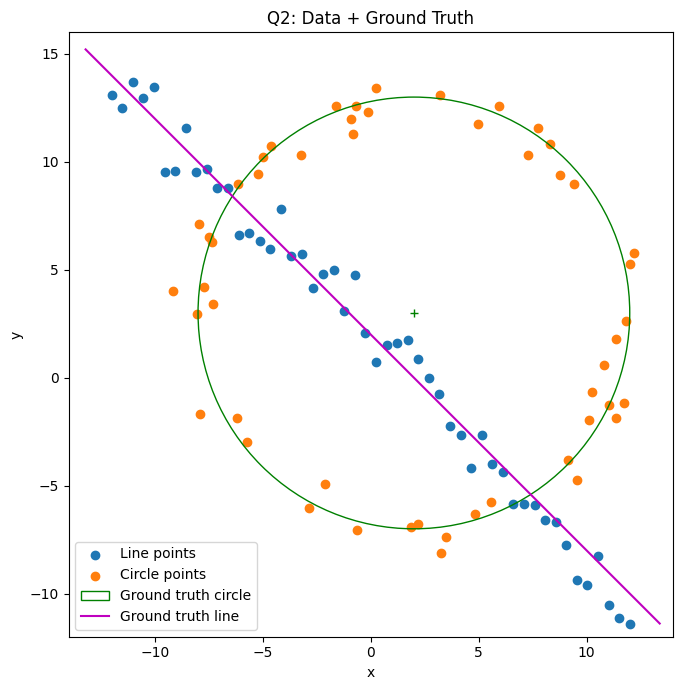

In [ ]:
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
import numpy as np

# np.random.seed(0)

N = 100
half_n = N//2

# ---- Circle points (assignment style) ----
r = 10
x0_gt, y0_gt = 2, 3  # Center
s = r/16
t = np.random.uniform(0, 2*np.pi, half_n)
n = s*np.random.randn(half_n)
x = x0_gt + (r + n)*np.cos(t)
y = y0_gt + (r + n)*np.sin(t)
X_circ = np.hstack((x.reshape(half_n,1), y.reshape(half_n,1)))

# ---- Line points ----
s = 1.
m_gt, b_gt = -1, 2  # y = mx + b
x = np.linspace(-12, 12, half_n)
y = m_gt*x + b_gt + s*np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n,1), y.reshape(half_n,1)))

# ---- Combined set ----
X = np.vstack((X_circ, X_line))

# ---- Plot points + GT models ----
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.scatter(X_line[:, 0], X_line[:, 1], label='Line points')
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle points')

# GT circle
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)
ax.plot([x0_gt], [y0_gt], '+', color='g')

# GT line
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m_gt * x_ + b_gt
ax.plot(x_, y_, color='m', label='Ground truth line')

ax.set_aspect('equal')
ax.set_xlim(-14, 14); ax.set_ylim(-12, 16)
ax.set_title('Q2: Data + Ground Truth')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend()
plt.tight_layout(); plt.show()

# RNG just for RANSAC sampling later (keeps line/circle generation identical to np.random above)
rng = np.random.default_rng(42)


### RANSAC line (unit-normal), inline

Line (unit normal): a=-0.724689, b=-0.689076, d=1.238263,  ||n||=1.000000
Inliers: 53/100  →  53.0%
Best sample indices (2 pts): [74 91]


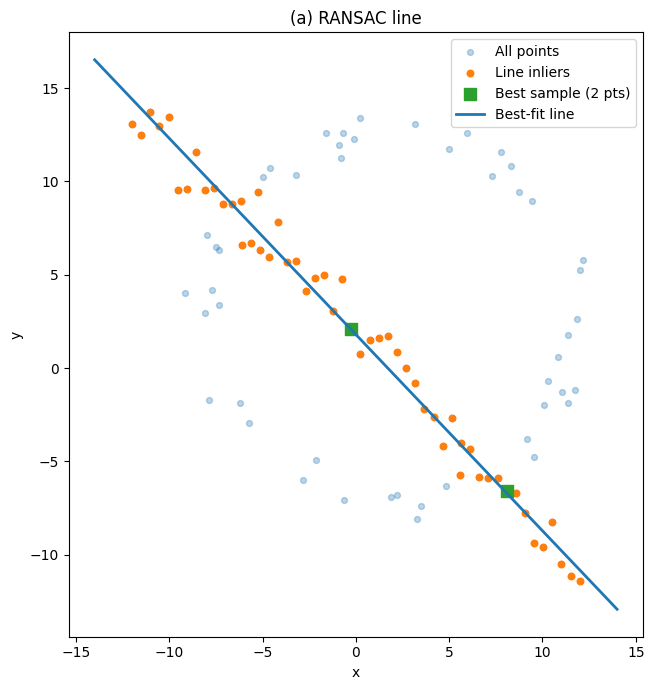

In [ ]:
iters = 1000
thr = 1.6
min_consensus = 20

best_count = 0
best_a = best_b = best_d = None
best_inliers = None
best_sample = None

for _ in range(iters):
    i, j = rng.choice(len(X), 2, replace=False)
    p, q = X[i], X[j]
    v = q - p
    if np.allclose(v, 0):
        continue
    # unit normal to v
    nrm = np.linalg.norm(v)
    a, b = v[1]/nrm, -v[0]/nrm
    d = -(a*p[0] + b*p[1])

    # distances with unit normal
    err = np.abs(a*X[:,0] + b*X[:,1] + d)
    inliers = err < thr
    k = int(inliers.sum())
    if k > best_count and k >= min_consensus:
        # refine via SVD on inliers
        P = X[inliers]
        mu = P.mean(axis=0)
        U, S, Vt = np.linalg.svd(P - mu)
        a2, b2 = Vt[-1] / np.linalg.norm(Vt[-1])
        d2 = -(a2*mu[0] + b2*mu[1])

        best_count = k
        best_a, best_b, best_d = a2, b2, d2
        best_inliers = inliers
        best_sample = np.array([i, j])

print(f"Line (unit normal): a={best_a:.6f}, b={best_b:.6f}, d={best_d:.6f},  ||n||={np.hypot(best_a,best_b):.6f}")
print(f"Inliers: {best_count}/{len(X)}  →  {100*best_count/len(X):.1f}%")
print('Best sample indices (2 pts):', best_sample)

# Plot
xx = np.array([-14.0, 14.0])
yy = -(best_a*xx + best_d)/best_b

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(X[:,0], X[:,1], s=18, alpha=0.3, label='All points')
ax.scatter(X[best_inliers,0], X[best_inliers,1], s=22, label='Line inliers')
ax.scatter(X[best_sample,0], X[best_sample,1], s=80, marker='s', label='Best sample (2 pts)')
ax.plot(xx, yy, linewidth=2, label='Best-fit line')
ax.set_aspect('equal'); ax.set_title('(a) RANSAC line'); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend()
plt.tight_layout(); plt.show()


### Remove line inliers and run circle RANSAC on remaining points (inline)

Circle center=(1.8734, 2.7517),  R=9.9982
Inliers: 45/47  →  95.7%
Best sample indices (3 pts in remnant set): [31 40 11]


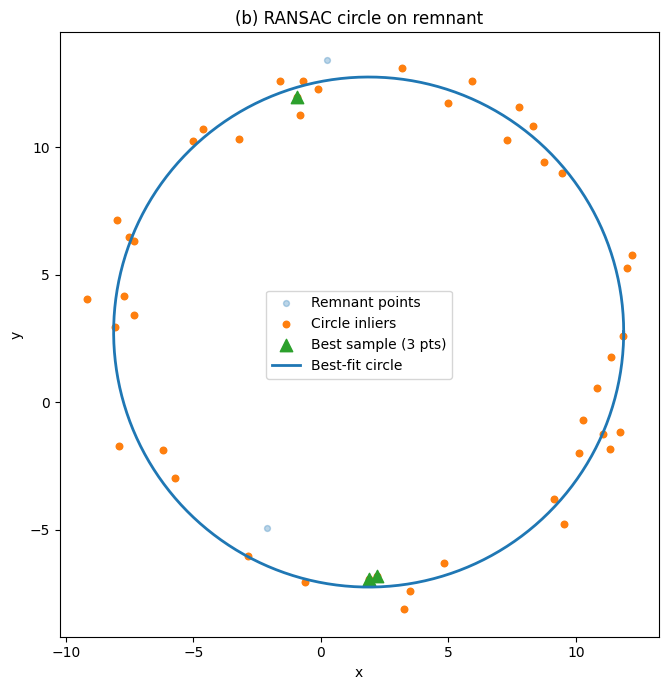

In [ ]:
X_rem = X[~best_inliers]

iters_c = 1000
thr_c = 1.5
min_consensus_c = 10
R_cap = 100.0

bestC_count = 0
best_x0 = best_y0 = best_R = None
bestC_inliers = None
bestC_sample = None

for _ in range(iters_c):
    idx = rng.choice(len(X_rem), 3, replace=False)
    p, q, r3 = X_rem[idx]

    # Circle from 3 points (determinants)
    A = np.array([[p[0], p[1], 1],
                  [q[0], q[1], 1],
                  [r3[0], r3[1], 1]], dtype=float)
    detA = np.linalg.det(A)
    if np.isclose(detA, 0):
        continue

    B = np.array([[p[0]**2 + p[1]**2, p[1], 1],
                  [q[0]**2 + q[1]**2, q[1], 1],
                  [r3[0]**2 + r3[1]**2, r3[1], 1]], dtype=float)
    C = np.array([[p[0], p[0]**2 + p[1]**2, 1],
                  [q[0], q[0]**2 + q[1]**2, 1],
                  [r3[0], r3[0]**2 + r3[1]**2, 1]], dtype=float)
    D = np.array([[p[0], p[1], p[0]**2 + p[1]**2],
                  [q[0], q[1], q[0]**2 + q[1]**2],
                  [r3[0], r3[1], r3[0]**2 + r3[1]**2]], dtype=float)

    dx = -np.linalg.det(B)
    dy =  np.linalg.det(C)
    c_det = -np.linalg.det(D)

    x0 = dx/(2*detA)
    y0 = dy/(2*detA)
    R = np.sqrt((dx**2 + dy**2)/(4*detA*detA) - c_det/detA)
    if not (np.isfinite(R) and 0 < R < R_cap):
        continue

    # radial-distance errors
    dist = np.hypot(X_rem[:,0]-x0, X_rem[:,1]-y0)
    err = np.abs(dist - R)
    inliers = err < thr_c
    k = int(inliers.sum())
    if k > bestC_count and k >= min_consensus_c:
        # tiny algebraic LS refine
        P = X_rem[inliers]; x = P[:,0]; y = P[:,1]
        A_ls = np.c_[x, y, np.ones_like(x)]
        b_ls = x*x + y*y
        c = np.linalg.lstsq(A_ls, b_ls, rcond=None)[0]
        x0r, y0r = c[0]/2, c[1]/2
        Rr = np.sqrt(c[2] + x0r*x0r + y0r*y0r)

        bestC_count = k
        best_x0, best_y0, best_R = x0r, y0r, Rr
        bestC_inliers = inliers
        bestC_sample = idx

print(f"Circle center=({best_x0:.4f}, {best_y0:.4f}),  R={best_R:.4f}")
print(f"Inliers: {bestC_count}/{len(X_rem)}  →  {100*bestC_count/len(X_rem):.1f}%")
print('Best sample indices (3 pts in remnant set):', bestC_sample)

# Plot
theta = np.linspace(0, 2*np.pi, 360)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(X_rem[:,0], X_rem[:,1], s=18, alpha=0.3, label='Remnant points')
ax.scatter(X_rem[bestC_inliers,0], X_rem[bestC_inliers,1], s=22, label='Circle inliers')
ax.scatter(X_rem[bestC_sample,0], X_rem[bestC_sample,1], s=80, marker='^', label='Best sample (3 pts)')
ax.plot(best_x0 + best_R*np.cos(theta), best_y0 + best_R*np.sin(theta), linewidth=2, label='Best-fit circle')
ax.set_aspect('equal'); ax.set_title('(b) RANSAC circle on remnant'); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend()
plt.tight_layout(); plt.show()


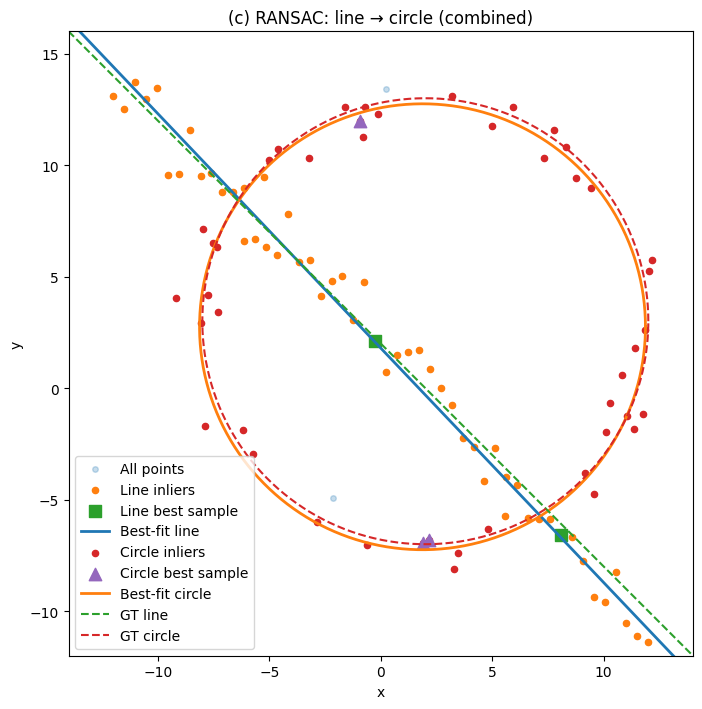

In [19]:
# Cell 4 — (c) Combined: all points, best samples, inliers, and best-fit models

fig, ax = plt.subplots(figsize=(7.2, 7.2))
ax.scatter(X[:,0], X[:,1], s=16, alpha=0.25, label='All points')

# line stuff
ax.scatter(X[best_inliers,0], X[best_inliers,1], s=20, label='Line inliers')
ax.scatter(X[best_sample,0], X[best_sample,1], s=80, marker='s', label='Line best sample')
xx = np.array([-14.0, 14.0])
yy = -(best_a*xx + best_d)/best_b
ax.plot(xx, yy, linewidth=2, label='Best-fit line')

# circle stuff
ax.scatter(X_rem[bestC_inliers,0], X_rem[bestC_inliers,1], s=20, label='Circle inliers')
ax.scatter(X_rem[bestC_sample,0], X_rem[bestC_sample,1], s=80, marker='^', label='Circle best sample')
theta = np.linspace(0, 2*np.pi, 360)
ax.plot(best_x0 + best_R*np.cos(theta), best_y0 + best_R*np.sin(theta), linewidth=2, label='Best-fit circle')

# also overlay GT for reference (dashed)
ax.plot(xx, m_gt*xx + b_gt, linestyle='--', label='GT line')
ax.plot(x0_gt + r*np.cos(theta), y0_gt + r*np.sin(theta), linestyle='--', label='GT circle')

ax.set_aspect('equal'); ax.set_xlim(-14, 14); ax.set_ylim(-12, 16)
ax.set_title('(c) RANSAC: line → circle (combined)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend()
plt.tight_layout(); plt.show()


**Cell 5 — (d) If we fit the circle first:**  
Line points can fall near the correct radius due to noise, so a circle-first RANSAC often accepts them as false inliers. That corrupts the circle fit and leaves a weaker set for the line. With this mixture, doing the **line first** is more robust.
